<center> 

# DSSI: Summer 2025
    
## Math for Machine Learning - Linear Algebra

#### Authored by: Bill Trok<center>


<center>
<img src="https://raw.githubusercontent.com/amandakube/Data118LectureImages/main/UChicago_DSI.png" alt="UC-DSI" width="300" height="100">
</center>

In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

## This Notebook

* Linear Algebra

## Vectors

In a sense these are the most basic objects in linear algebra. You are already seen these, whenever you used ``np.array``.

In [3]:
# Example of a vector
vec = np.array([1,3,0,-12.0])
vec

array([  1.,   3.,   0., -12.])

Mathematically speaking you can think of a vector as just a list of numbers. They come with associated operations. Two vectors can be added and subtracted, but only if they have the same length.

In [4]:
vecA = np.array([1,3,0,-12.0])
vecB = np.array([0,3,-1.1])
vecC = np.array([-2.1,-0.5,1.4])

In [5]:
# Adding two vectors adds entry wise 
print(vecB)
print(vecC)
print(vecB + vecC)

[ 0.   3.  -1.1]
[-2.1 -0.5  1.4]
[-2.1  2.5  0.3]


In [6]:
# vectors of different sizes cannot be added up
vecA + vecB

ValueError: operands could not be broadcast together with shapes (4,) (3,) 

## Scalars

When dealing with things like vectors, we often use the term "scalar" to refer to ordinary numbers. We can multiply/divide/add/subtract a vector by a scalar. This is done by caring out each operation on each entry.

In [7]:
print("A  :",vecA)
print("4*A:",4*vecA)
print("A+4:",vecA+4)


A  : [  1.   3.   0. -12.]
4*A: [  4.  12.   0. -48.]
A+4: [ 5.  7.  4. -8.]


## Multiplications

Multiplication is a bit more complicated. There are (at least) two different ways to multiply vectors. The first kind is probably the most familiar to you, entry-wise multiplication which is carried out via the standard multiplication operation.

In [8]:
print(vecC)
print(vecB)
print(vecC*vecB)

[-2.1 -0.5  1.4]
[ 0.   3.  -1.1]
[-0.   -1.5  -1.54]


The other type of vector multiplication that is very common is known as the dot product. This is the sum of the entry-wise product of two vectors.

In [9]:
A = np.array([1,0,-1,5])
B = np.array([5,3,4,-2])
print("entry-wise product:",A*B)
print("Dot Product:", sum(A*B))

entry-wise product: [  5   0  -4 -10]
Dot Product: -9


There are multiple ways to compute a dot product.

In [10]:
print(sum(A*B))
print(np.dot(A,B))
print(A@B)


-9
-9
-9


## Glimpse into Geometry

Vectors have an associated geometric picture. We can think of the vector $\langle x,y\rangle = $ ``np.array([x,y])`` as denoting the arrow from the origin $(0,0)$ to the point $(x,y)$.

Below we have a picture of the vectors $\langle{1,2}\rangle$ and $\langle{3,-1}\rangle$.

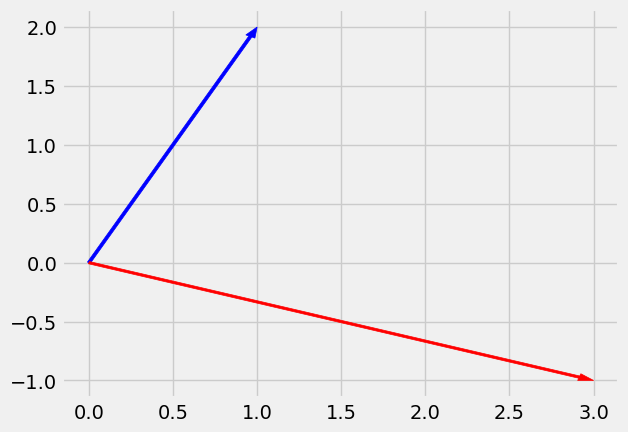

In [32]:
a = plt.arrow(0,0,1,2,width=0.02,color="blue",length_includes_head=True);
b = plt.arrow(0,0,3,-1,width=0.02,color="red",length_includes_head=True);
plt.show()

## Geometry of Vector Operations
### Vector Addition

Below we see the geometric picture behind vector addition. The green vector is the sum of the red and blue vectors.

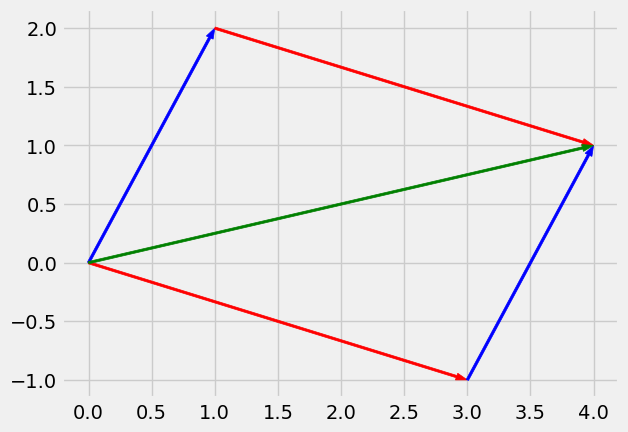

In [28]:
plt.arrow(0,0,1,2,width=0.02,color="blue",length_includes_head=True);
plt.arrow(0,0,3,-1,width=0.02,color="red",length_includes_head=True);
plt.arrow(3,-1,1,2,width=0.02,color="blue",length_includes_head=True);
plt.arrow(1,2,3,-1,width=0.02,color="red",length_includes_head=True);
plt.arrow(0,0,4,1,width=0.02,color="green",length_includes_head=True);
plt.show()

### Scalar Multiplication
Multiplying a vector by a scalar preserves the direction (or flips it) but changes the length of the vector.

Here we see the original vector $\langle 1,2 \rangle$ in blue, the vector $2 \times \langle 1,2 \rangle$ in red, and the vector $-1 \times \langle 1,2 \rangle$ in green. 

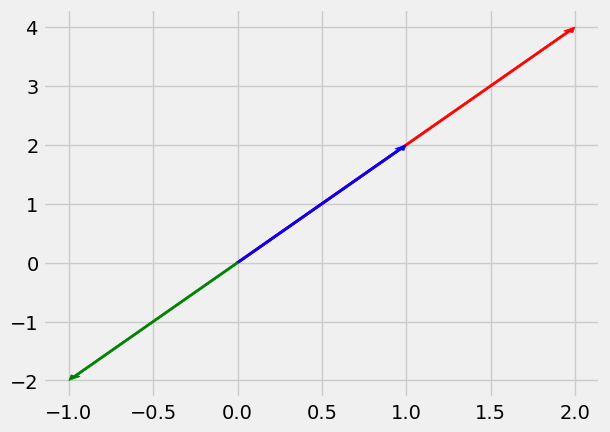

In [38]:
plt.arrow(0,0,2,4,width=0.02,color="red",length_includes_head=True);
plt.arrow(0,0,1,2,width=0.02,color="blue",length_includes_head=True);
plt.arrow(0,0,-1,-2,width=0.02,color="green",length_includes_head=True)

### Vector Norm

The norm $\| A\|$ of a vector $A = \langle a_1,a_2,a_3,..,a_n \rangle $ is given by the formula

$$\| A \| = \sqrt{a_1^2+a_2^2+\ldots +a_n^2}$$

In [39]:
print("  A  = ", A)
print("||A||= ",np.linalg.norm(A))
print("||A||= ",np.sqrt(A@A))

  A  =  [ 1  0 -1  5]
||A||=  5.196152422706632
||A||=  5.196152422706632


### Dot Product

The dot product of two vectors $A = \langle a_1,a_2,..,a_n \rangle$ and $B = \langle b_1,b_2,..,b_n\rangle$ also has geometric meaning.

$$ A \cdot B = a_1b_1+a_2b_2+...a_nb_n$$
If $\theta$ is the angle between the vectors then 
$$ A \cdot B = \|A\|\|B\| \cos(\theta)$$

## Matrices

A $n$ by $k$ matrix is a grid of numbers with $n$ rows and $k$ columns.

$$A = \begin{bmatrix}1&4&-2\\
7&1&0\end{bmatrix}$$

We can define it in numpy as an array of $n$ vectors each of which has size $k$.

In [79]:
A = np.array([[1,4,-2],
              [7,1,0]])
print(A.shape)
A

(2, 3)


array([[ 1,  4, -2],
       [ 7,  1,  0]])

Attempting to define a matrix using vectors of different sizes will result in an error.

In [80]:
B = np.array([[2,5,1,0],
              [3,10,-1],
              [5,0,1.1,6]])
B

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (3,) + inhomogeneous part.

In [81]:
B = np.array([[2,5,1,0],
              [3,10,-1,1.2],
              [5,0,1.1,6]])
print(B.shape)
B

(3, 4)


array([[ 2. ,  5. ,  1. ,  0. ],
       [ 3. , 10. , -1. ,  1.2],
       [ 5. ,  0. ,  1.1,  6. ]])

## Matrix Operations

Matrices can be multiplied/added by a scalar just like vectors.

Additionally, two matrices with the same shape can be added or multiplied entrywise.

In [87]:
print(A)
print(2*A)
print(A+1)

[[ 1  4 -2]
 [ 7  1  0]]
[[ 2  8 -4]
 [14  2  0]]
[[ 2  5 -1]
 [ 8  2  1]]


In [91]:
C = np.array([[0,1.1,3],
              [-1,0,0]])
print("A\n",A)
print("C\n",C)
print("C+A\n",C+A)
print("C*A\n",C*A)

A
 [[ 1  4 -2]
 [ 7  1  0]]
C
 [[ 0.   1.1  3. ]
 [-1.   0.   0. ]]
C+A
 [[1.  5.1 1. ]
 [6.  1.  0. ]]
C*A
 [[ 0.   4.4 -6. ]
 [-7.   0.   0. ]]


### Matrix Product

There is also a matrix product. However, unlike with vectors two matrices with the same shape cannot necessarily be multiplied. 

In [92]:
A@C

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 3)

We instead can always multiply a n by k matrix with a k by m matrix. To get a n by m matrix.

$$\begin{aligned}
\begin{bmatrix} 3&4\\-1&2 \\0&1\end{bmatrix} \begin{bmatrix} 11&0&1.1\\
7 & 3&-0.5\end{bmatrix} &= \begin{bmatrix} 3(11)+4(7) & 3(0)+4(3) & 3(1.1)+4(-0.5)\\
-1(11)+2(7) & -1(0)+2(3) & -1(1.1)+2(-0.5)\\
0(11)+1(7) & 0(0)+1(3) & 0(1.1)+1(-0.5)\\
\end{bmatrix}\\
&= \begin{bmatrix}61 &12 & 1.3\\
3 & 6 & -2.1\\
7 & 3 & -0.5\end{bmatrix}
\end{aligned}$$

Note that the entries of the first row are obtained by taking the dot product of the first row of the first matrix with the columns of the second matrix. Hence, why we need the length of the rows in the first matrix to match the number of rows in the second.

In [94]:
D = np.array([[3,4],
              [-1,2],
              [0,1]])
C = np.array([[11,0,1.1],
              [7,3,-0.5]])
D@C

array([[61. , 12. ,  1.3],
       [ 3. ,  6. , -2.1],
       [ 7. ,  3. , -0.5]])

## Transpose

An important concept when dealing with matrices is that of the transpose. Any matrix has a transpose which is obtained by swapping the rows for the columns and vice versa.

$$\begin{bmatrix} 3&4\\-1&2 \\0&1\end{bmatrix} ^T = \begin{bmatrix} 3&-1 & 0\\
4&2&1\end{bmatrix} $$

The transpose of a matrix ``A`` in numpy is obtain as attribute ``A.T``.

In [98]:
print("A:\n",A)
print("A transpose:\n",A.T)

A:
 [[ 1  4 -2]
 [ 7  1  0]]
A transpose:
 [[ 1  7]
 [ 4  1]
 [-2  0]]


## Tensors

Finally we get to tensors, this is more general than vectors and matrices. A $1$-way tensor is a vector, a $2$-way tensor is a matrix, and more generally a $k$-way tensor is a list of $k-1$-way tensors all of which have the same shape. 

For instance a $3$-way tensor is a list of matrices all of which have the same shape.

In [5]:
T = np.array([[[1,2],[3,4],[5,6],[7,8]],
             [[0,12],[13,-1],[8,0.5],[1,8]],
             [[1,-2],[4,0.5],[8,1.5],[0,0]]])
print(T.shape)
T

(3, 4, 2)


array([[[ 1. ,  2. ],
        [ 3. ,  4. ],
        [ 5. ,  6. ],
        [ 7. ,  8. ]],

       [[ 0. , 12. ],
        [13. , -1. ],
        [ 8. ,  0.5],
        [ 1. ,  8. ]],

       [[ 1. , -2. ],
        [ 4. ,  0.5],
        [ 8. ,  1.5],
        [ 0. ,  0. ]]])

## Accessing Elements

We can access elements of a tensor using repeated ``[]`` brackets.

In [6]:
T[1]

array([[ 0. , 12. ],
       [13. , -1. ],
       [ 8. ,  0.5],
       [ 1. ,  8. ]])

In [7]:
T[1][2]

array([8. , 0.5])

In [8]:
T[1][2][0]

8.0

## Pencil and Paper Activity

Answer the following Questions.

### Question 1

What is the dimensions of the following matrix?

$$\begin{bmatrix} 1&4&0 \\
3&2&12\\
0&1.1 &-1\\
0&0&0\\
6&0&10\end{bmatrix}$$

### Question 2
For each of the following determine if you can add the following matrices. If you can find the sum.

a) $$ \begin{bmatrix} -1 & 0\\
3&9\end{bmatrix} + \begin{bmatrix} 0 & 10\\
12&-7\end{bmatrix}$$

b) $$ \begin{bmatrix} 3 & 4\end{bmatrix}
+ \begin{bmatrix} 12 & 10\\
1&-1\end{bmatrix}$$

### Question 3

Consider the code snippets below. What would the result be?

a) 
```python
a = np.array([1,3,0,6])
print(a[2])
```

b) 
```python
b = np.array([[2,-3,0],[0,4,5]])
print(b[1][2])
``` 

c) 
```python
c = np.array([[2,-3,0,1],[0,12,4,5],[5,0,7,11]])
print(c.T[2])
```



### Question 4

Find the following matrix product

$$\begin{bmatrix} 
12&0.7&-1\\
0&0.5&1\\
9&5&-4
\end{bmatrix} \begin{bmatrix} 
1\\ 3 \\ 10
\end{bmatrix}$$

### Question 5

Find the following matrix product

$$\begin{bmatrix} 
11&0.5&8\\
1&4&7
\end{bmatrix} \begin{bmatrix} 
1&-3\\ 
-4&0 
\end{bmatrix}$$

### Question 6

(WITHOUT COPYING AND PASTING) Determine if the following code would define a tensor. If it would what would the dimension be. If not why not.

a) 

```python
a = np.array([[0,0,1,12],[0,1,14],[0,1,2,3]]
```

b) 

```python
b = np.array([[[0,0,1],[0,1,14],[0,1,3]],
            [[0,0,1],[0,1,2],[-1,0.5,0]]])
```

c) 
```python
c = np.array([[[0,1],[1,14],[0,1]],
            [[0,0],[1,2],[0.5,0]],
            [[0,0],[1,2],[0.5,0]],
            [[0,0],[1,2],[0.5,0]]])
```

## Torch

All of these operations can also be carried out in the library ``torch``. 

In [6]:
import torch 

print(torch.tensor([0,1,3]))

tensor([0, 1, 3])


We can freely convert between torch tensors and numpy tensors.

In [18]:
A = np.array([[1.0,4,-2],
              [7,1,0]])
C = np.array([[0,1.1,3],
              [-1,0,0]])
torchA = torch.tensor(A)
torchC = torch.tensor(C)
print("torchA",torchA)
print("torchC",torchC)

torchA tensor([[ 1.,  4., -2.],
        [ 7.,  1.,  0.]], dtype=torch.float64)
torchC tensor([[ 0.0000,  1.1000,  3.0000],
        [-1.0000,  0.0000,  0.0000]], dtype=torch.float64)


Operations are carried out identically in both.

In [19]:
print(A+C)
print(torchA+torchC)

[[1.  5.1 1. ]
 [6.  1.  0. ]]
tensor([[1.0000, 5.1000, 1.0000],
        [6.0000, 1.0000, 0.0000]], dtype=torch.float64)


In [20]:
print(A.T)
print(torchA.T)

[[ 1.  7.]
 [ 4.  1.]
 [-2.  0.]]
tensor([[ 1.,  7.],
        [ 4.,  1.],
        [-2.,  0.]], dtype=torch.float64)


In [21]:
print(A@ C.T)
print((torchA) @ (torchC.T))

[[-1.6 -1. ]
 [ 1.1 -7. ]]
tensor([[-1.6000, -1.0000],
        [ 1.1000, -7.0000]], dtype=torch.float64)


## Broadcasting

It turns out you can add tensors of different sizes. This probably isn't familiar to you if you've taken linear algebra, but Python allows this as a convenience via broadcasting.

https://pytorch.org/docs/stable/notes/broadcasting.html

https://numpy.org/doc/stable/user/basics.broadcasting.html

In [24]:
A = np.array([[1,0,1],[3,4,5]])
print(A)
B = np.array([2,-7,0])
print(B)
B+A

[[1 0 1]
 [3 4 5]]


array([[ 3, -7,  1],
       [ 5, -3,  5]])

In [30]:
C = np.array([[-1,-5,-7]]).T
print("C\n",C)
print("B\n",B)
print("C+B (Broadcasted) \n",C+B)

C
 [[-1]
 [-5]
 [-7]]
B
 [ 2 -7  0]
C+B (Broadcasted) 
 [[  1  -8  -1]
 [ -3 -12  -5]
 [ -5 -14  -7]]


The idea behind this is that just as python allows you to add a scalar to a vector 
$$\begin{bmatrix} 3 & 7\end{bmatrix} + 2 = \begin{bmatrix} 5 & 9\end{bmatrix},$$

If a tensor is just a list of $2$ by $3$ matrices, we should be be able to add a 3 by 5 matrix to it. 

$$\left[ \begin{bmatrix} 3 & 7\\0&1\end{bmatrix}, \begin{bmatrix} 5 & -9\\0.5&1\end{bmatrix}\right] + \begin{bmatrix} 0 & -3\\1&2\end{bmatrix} = \left[ \begin{bmatrix} 3 & 4\\1&3\end{bmatrix}, \begin{bmatrix} 5 & -12\\1.5&3\end{bmatrix}\right]$$ 

The full picture is only slightly more complicated than this. In that we will allow a tensor```T = [t1,..,tn]``` and a tensor ```S = [s1,..,sk]``` to be broadcast together if ```S``` can be broadcast with ```ti```.

In [4]:
X = np.random.rand(5,2,3)
Y = np.random.rand(2,1)
X+Y

array([[[0.83247326, 0.96813332, 0.85212751],
        [1.1606203 , 1.58651307, 0.89285892]],

       [[0.50885735, 1.03953579, 1.11230494],
        [0.8818504 , 0.76126046, 0.78797499]],

       [[0.272438  , 0.71541331, 1.08927254],
        [0.99515303, 1.27909811, 0.76653092]],

       [[0.71618113, 0.81813847, 0.83856042],
        [1.42319866, 1.08735009, 0.79061973]],

       [[0.59081566, 1.00637658, 0.30922621],
        [0.85236163, 0.8351902 , 1.51695522]]])

## Activity

For each of the following determine if the two vectors can be broadcast. If they can be compute the sum.

## Exercise 1

```python
a = torch.tensor([[3,3],[1,4],[7,0]])
b = torch.tensor([[0,1],[12,9]])
a+b
```

## Exercise 2
```python
c = torch.tensor([[[3,3],[1,4]],
                  [[7,0],[2,2]]])
d = torch.tensor([[-1,1],[-2,7]])
c+d
```